# 05 · Anomaly detection (unsupervised)

* Models are fit on **normal training traffic only**; 20% of those normals are held out to set the alert threshold (95th percentile -> ~5% target FPR).
* Evaluation uses the full official **test split** (mixed traffic).
* **Sampling:** LOF is fit on 20,000 normals, One-Class SVM on 10,000, autoencoder (sklearn MLP) on 20,000. Isolation Forest uses all 44,800 fitting normals.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
SRC = Path.cwd().parent / 'src' if (Path.cwd().parent / 'src').exists() else Path.cwd() / 'src'
sys.path.insert(0, str(SRC))
import pandas as pd, json
from IPython.display import Image, Markdown, display
from config import FIG_DIR, METRICS_DIR, REPORTS_DIR, EXPORT_DIR
pd.set_option('display.max_columns', 60, 'display.width', 200)
def show(name, width=900):
    display(Image(filename=str(FIG_DIR / f'{name}.png'), width=width))

In [2]:
import anomaly
res = anomaly.run()


PHASE 6 - ANOMALY DETECTION (unsupervised)


Fit on 44,800 normal train flows; threshold set on 11,200 held-out normals; evaluate on 82,332 test flows (55.1% attacks)


Features: 61 (41 log1p-transformed numeric, RobustScaler, one-hot proto/service/state)


   [IsolationForest] 1.5s


   [LOF (novelty, sample 20,000)] 1.7s


...

   [score IsolationForest] 2.1s


   [score LocalOutlierFactor] 6.6s


   [score OneClassSVM] 8.1s


   [score Autoencoder] 0.2s
             model  precision  recall_attack     f1  roc_auc  pr_auc    fpr
   IsolationForest     0.9130         0.6631 0.7682   0.8684  0.8945 0.0775
LocalOutlierFactor     0.8969         0.5997 0.7188   0.7873  0.8125 0.0845
       Autoencoder     0.6379         0.1532 0.2470   0.6959  0.6663 0.1065
       OneClassSVM     0.7183         0.2016 0.3149   0.6273  0.6307 0.0969
Best anomaly model by PR-AUC: IsolationForest


Flag rate per class (best model):
                 flows  flag_rate
attack_cat                      
Generic         18871      0.967
Backdoor          583      0.916
Analysis          677      0.916
DoS              4089      0.774
Exploits        11132      0.478
Fuzzers          6062      0.284
Worms              44      0.205
Reconnaissance   3496      0.119
Normal          37000      0.077
Shellcode         378      0.037


In [3]:
pd.DataFrame(res['comparison'])[['model','precision','recall_attack','f1','roc_auc','pr_auc','fpr','tp','fp','tn','fn']]

,model,precision,recall_attack,f1,roc_auc,pr_auc,fpr,tp,fp,tn,fn
0,IsolationForest,0.9130,0.6631,0.7682,0.8684,0.8945,0.0775,30058,2866,34134,15274
1,LocalOutlierFactor,0.8969,0.5997,0.7188,0.7873,0.8125,0.0845,27185,3125,33875,18147
2,Autoencoder,0.6379,0.1532,0.2470,0.6959,0.6663,0.1065,6943,3941,33059,38389
3,OneClassSVM,0.7183,0.2016,0.3149,0.6273,0.6307,0.0969,9140,3584,33416,36192


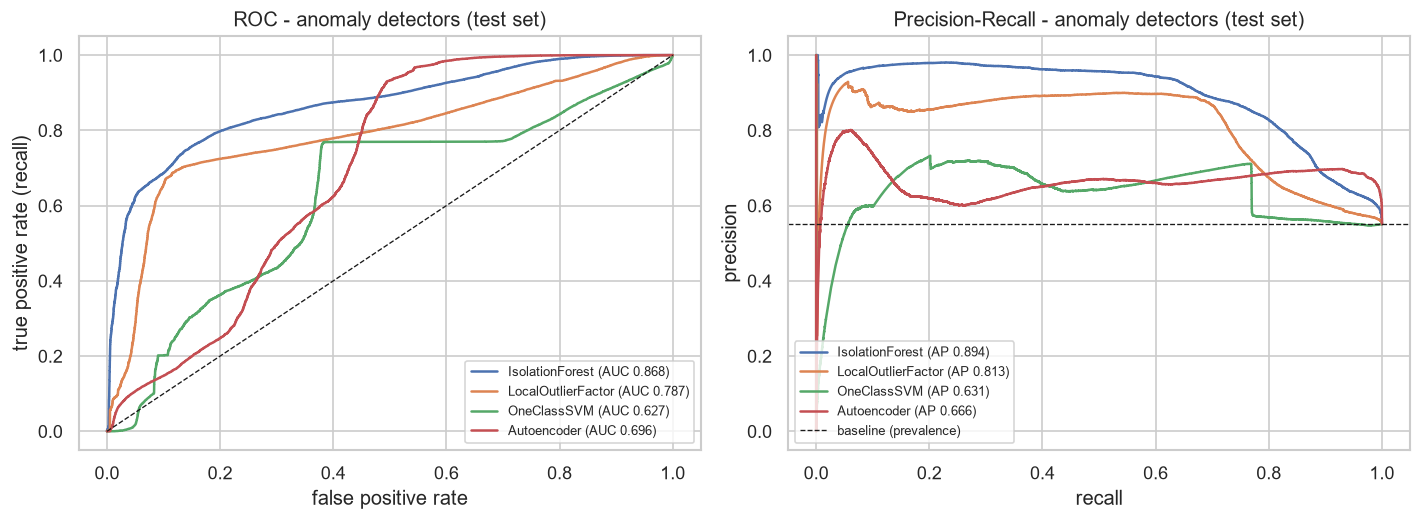

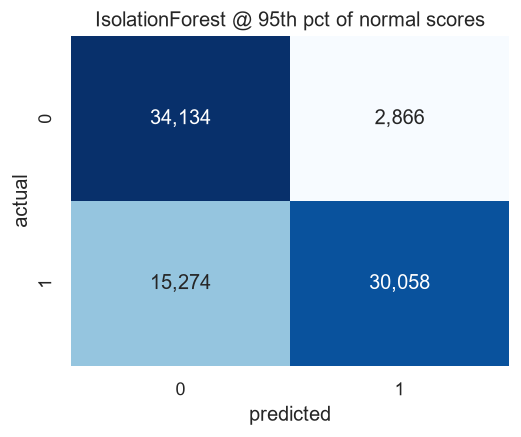

In [4]:
show('06_anomaly_roc_pr', 1000)
show('06_anomaly_confusion', 420)

## Which attacks look anomalous?
Volume-style attacks (Generic, DoS) stand out; low-and-slow or payload-style attacks (Reconnaissance, Shellcode, Worms) resemble normal flows and are missed.

In [5]:
pd.DataFrame(res['detection_by_category'])

,attack_cat,flows,flag_rate
0,Generic,18871,0.967410
1,Backdoor,583,0.915952
2,Analysis,677,0.915805
3,DoS,4089,0.773539
4,Exploits,11132,0.478441
5,Fuzzers,6062,0.283570
6,Worms,44,0.204545
7,Reconnaissance,3496,0.119279
8,Normal,37000,0.077459
9,Shellcode,378,0.037037
